In [ ]:
from google.colab import files
files.upload()  # this will prompt a file picker — select your kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shreyraveshia","key":"b4f67cda1a53b07c1dd284d00bb88aba"}'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!pip install kaggle --quiet

In [ ]:
!kaggle competitions download -c kkbox-churn-prediction-challenge -f train.csv
!kaggle competitions download -c kkbox-churn-prediction-challenge -f members_v3.csv
!kaggle competitions download -c kkbox-churn-prediction-challenge -f transactions.csv

404 Client Error: Not Found for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFile
404 Client Error: Not Found for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFile
404 Client Error: Not Found for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFile


In [ ]:
!pip install --upgrade kaggle --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 23.0 MB/s eta 0:00:00


In [ ]:
!kaggle competitions download -c kkbox-churn-prediction-challenge

100% 8.34G/8.34G [01:26<00:00, 103MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('kkbox-churn-prediction-challenge.zip', 'r') as z:
    names = z.namelist()
    print(names)  # let's first see exactly what's inside

['WSDMChurnLabeller.scala', 'members_v3.csv.7z', 'sample_submission_v2.csv.7z', 'sample_submission_zero.csv.7z', 'train.csv.7z', 'train_v2.csv.7z', 'transactions.csv.7z', 'transactions_v2.csv.7z', 'user_logs.csv.7z', 'user_logs_v2.csv.7z']


In [ ]:
!pip install py7zr --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 15.6 MB/s eta 0:00:00


In [ ]:
import zipfile
import py7zr

# First, pull the needed .7z files out of the outer zip
with zipfile.ZipFile('kkbox-churn-prediction-challenge.zip', 'r') as z:
    z.extract('train.csv.7z')
    z.extract('members_v3.csv.7z')
    z.extract('transactions.csv.7z')

# Now extract the actual CSVs from each .7z
for f in ['train.csv.7z', 'members_v3.csv.7z', 'transactions.csv.7z']:
    with py7zr.SevenZipFile(f, mode='r') as archive:
        archive.extractall()

print("Done")

Done


In [ ]:
!ls -lh *.csv

-rw-rw-r-- 1 root root 409M Nov 13  2017 members_v3.csv
-rw-rw-r-- 1 root root  45M Sep 14  2017 train.csv
-rw-rw-r-- 1 root root 1.7G Sep 14  2017 transactions.csv


In [ ]:
import pandas as pd

train = pd.read_csv('train.csv')
print(train.shape)
train.head()

(992931, 2)


,msno,is_churn
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1


In [ ]:
members = pd.read_csv('members_v3.csv')
print(members.shape)
members.head()

(6769473, 6)


,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [ ]:
transactions = pd.read_csv('transactions.csv')
print(transactions.shape)
transactions.head()

(21547746, 9)


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,YyO+tlZtAXYXoZhNr3Vg3+dfVQvrBVGO8j1mfqe4ZHc=,41,30,129,129,1,20150930,20151101,0
1,AZtu6Wl0gPojrEQYB8Q3vBSmE2wnZ3hi1FbK1rQQ0A4=,41,30,149,149,1,20150930,20151031,0
2,UkDFI97Qb6+s2LWcijVVv4rMAsORbVDT2wNXF0aVbns=,41,30,129,129,1,20150930,20160427,0
3,M1C56ijxozNaGD0t2h68PnH2xtx5iO5iR2MVYQB6nBI=,39,30,149,149,1,20150930,20151128,0
4,yvj6zyBUaqdbUQSrKsrZ+xNDVM62knauSZJzakS9OW4=,39,30,149,149,1,20150930,20151121,0


In [ ]:
!git config --global user.email "shreyraveshia07@gmail.com"
!git config --global user.name "shreyraveshia"

In [ ]:
!git clone https://github.com/shreyraveshia/ott-causal-uplift-modeling.git

Cloning into 'ott-causal-uplift-modeling'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), done.


In [ ]:
%cd ott-causal-uplift-modeling
# do work, save notebook here, create files here

/content/ott-causal-uplift-modeling


In [ ]:
from google.colab import files
uploaded = files.upload()  # select the .ipynb you just downloaded

Saving sony_uplift_project.ipynb to sony_uplift_project.ipynb


In [ ]:
from google.colab import userdata
token = userdata.get('GH_TOKEN')

A single user has multiple rows because the transactions.csv file tracks historical events over time.

Every single time a user renews their subscription, changes their payment method, updates their plan, or cancels their account, a new row is added.

Because millions of users have been with the platform for months or years (renewing month after month), the transaction ledger grows exponentially to 21.5 million rows.

 Why members_v3 Has Way More Users Than train.csv:-
 1. members_v3.csv is the entire historic user base

 2. train.csv is a strict, target observation window

 It comes down to historical lifetime database entries versus a specific time-window snapshot

## Level 2 — Behavior & Value Feature Engineering

2.1 — First, shrinking the data to just the users we care about

In [ ]:
# Keep only users who appear in our labeled training set
labeled_users = set(train['msno'])

members_filtered = members[members['msno'].isin(labeled_users)].copy()
transactions_filtered = transactions[transactions['msno'].isin(labeled_users)].copy()

print("Members filtered:", members_filtered.shape)
print("Transactions filtered:", transactions_filtered.shape)

Members filtered: (877161, 6)
Transactions filtered: (15883148, 9)


In [ ]:
# labeled_users = set(train['msno']):- meaning
#Extracts the unique user identifiers (msno) from the train DataFrame.
#Converts them into a Python set for high-speed lookups.

2.2 — Aggregating transactions into one row per user

Understanding what "value" and "behavior" mean here

thinking about what signals in 'transactions_filtered' actually indicate engagement/value

-Since each user can have multiple transaction rows (they renew over time), we need to aggregate — collapse many rows into one summary row per user. This is the core technique of this step: group by user, compute summary stats.

In [ ]:
user_transaction_features = transactions_filtered.groupby('msno').agg(
    total_transactions=('transaction_date', 'count'),
    total_amount_paid=('actual_amount_paid', 'sum'),
    avg_amount_paid=('actual_amount_paid', 'mean'),
    avg_plan_days=('payment_plan_days', 'mean'),
    latest_transaction_date=('transaction_date', 'max'),
    is_auto_renew_latest=('is_auto_renew', 'last'),
    total_cancels=('is_cancel', 'sum'),
    cancel_rate=('is_cancel', 'mean'),
).reset_index()

print(user_transaction_features.shape)
user_transaction_features.head()

(992931, 9)


,msno,total_transactions,total_amount_paid,avg_amount_paid,avg_plan_days,latest_transaction_date,is_auto_renew_latest,total_cancels,cancel_rate
0,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,4,396,99.0,30.000000,20170215,1,0,0.0
1,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,19,2831,149.0,28.578947,20170131,1,0,0.0
2,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,26,3874,149.0,28.846154,20170226,1,0,0.0
3,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,12,1788,149.0,30.000000,20170215,1,0,0.0
4,++/UDNo9DLrxT8QVGiDi1OnWfczAdEwThaVyD0fXO50=,19,2831,149.0,28.578947,20170131,1,0,0.0


2.3 — Convert dates properly, compute recency

Right now latest_transaction_date is a number like 20170215. Let's convert it to a real date and compute recency — how many days before the "observation point" was their last transaction.

In [ ]:
# Convert to real datetime
user_transaction_features['latest_transaction_date'] = pd.to_datetime(
    user_transaction_features['latest_transaction_date'], format='%Y%m%d'
)

# Use the dataset's overall latest date as our "reference point" (since KKBox data is historical, not live)
reference_date = user_transaction_features['latest_transaction_date'].max()
print("Reference date:", reference_date)

# Recency = days between their last transaction and the reference point
user_transaction_features['recency_days'] = (
    reference_date - user_transaction_features['latest_transaction_date']
).dt.days

user_transaction_features[['msno', 'latest_transaction_date', 'recency_days']].head()

Reference date: 2017-02-28 00:00:00


,msno,latest_transaction_date,recency_days
0,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,2017-02-15,13
1,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,2017-01-31,28
2,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,2017-02-26,2
3,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,2017-02-15,13
4,++/UDNo9DLrxT8QVGiDi1OnWfczAdEwThaVyD0fXO50=,2017-01-31,28


Step 1: Converting Text/Numbers into Real Dates

-The Problem: Originally, the dates are stored as plain numbers like 20170215.

-To a computer, this is just twenty million, one hundred and seventy thousand, two hundred and fifteen. You cannot do calendar math (like subtracting days) with plain numbers.

-The Fix: pd.to_datetime() tells Pandas to look at that number and read it using a specific blueprint: %Y (4-digit year), %m (2-digit month), and %d (2-digit day).

-The Result: It transforms the number 20170215 into an official timestamp object: 2017-02-15.

Step 2: Finding the "End of Time" in the Data

-The Problem: To calculate how long ago a user did something, you need a baseline "Today". Because this is an old dataset, using your actual calendar today (in 2026) would make everyone look like they haven't logged in for 9 years, rendering the feature useless.

-The Fix: .max() scans the entire column and finds the absolute latest, most recent date present in the entire dataset.

-The Result: It freezes that exact day as your project's "Simulation Today" (the reference point).

Step 3: Calculating the Gap (Recency)

-The Math: The code subtracts each user's specific transaction date from the frozen reference_date.

-The Object: Subtracting two dates creates a Pandas "Timedelta" object (e.g., 3 days 00:00:00).

-The .dt.days Part: This strips away the time words and converts the gap into a clean, raw integer (like 3).

-The Result: You get a brand new column (recency_days) filled with simple numbers.

2.4 — Merge everything into one master user table


 Explanation of `how='left'` in the Merge


1.  **Guaranteed Retention of Left DataFrame:** A `left` merge explicitly states the intention to keep *all* rows from the left DataFrame (`train` in the first merge, and the result of that merge in the second). This is crucial when your left DataFrame represents your primary entities of interest (in this case, all users from the `train` set).

2.  **Robustness to Data Inconsistencies:** While the pre-filtering minimizes the chance, real-world data can sometimes have subtle inconsistencies. If, by some unforeseen error or an edge case in the data, a `msno` existed in `train` but *not* in `members_filtered` or `user_transaction_features` (despite the filtering efforts), a `left` merge would still retain that `train` record and simply fill the new columns with `NaN`s. An `inner` merge, on the other hand, would silently drop such a row.

3.  **Clear Intent:** It clearly communicates that the goal is to *augment* the `train` (or `master`) DataFrame with additional information

In [ ]:
master = train.merge(members_filtered, on='msno', how='left')
master = master.merge(user_transaction_features, on='msno', how='left')

print(master.shape)
master.head()

(992931, 16)


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,total_transactions,total_amount_paid,avg_amount_paid,avg_plan_days,latest_transaction_date,is_auto_renew_latest,total_cancels,cancel_rate,recency_days
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1,18.0,36.0,female,9.0,20050406.0,2,149,74.500000,18.500000,2017-01-07,0,0,0.000000,52
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1,10.0,38.0,male,9.0,20050407.0,23,3458,150.347826,28.826087,2017-02-24,1,2,0.086957,4
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1,11.0,27.0,female,9.0,20051016.0,10,1492,149.200000,30.000000,2017-01-12,0,1,0.100000,47
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1,13.0,23.0,female,9.0,20051102.0,2,1788,894.000000,410.000000,2016-01-06,0,0,0.000000,419
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1,3.0,27.0,male,9.0,20051228.0,8,3576,447.000000,98.125000,2017-01-28,0,0,0.000000,31


2.5 — Check for missing values and weird outliers

### What the Missing Values Tell Us

Your interpretation of the missing values is mostly accurate and highlights a crucial aspect of merging datasets!

**1. Missing Membership Information (115,770 rows):**

*   **Columns affected:** `city`, `bd`, `registered_via`, `registration_init_time`.
*   **What it means:** These columns all originate from the `members_filtered` DataFrame. When you performed the first `master = train.merge(members_filtered, on='msno', how='left')`, you essentially told pandas: "Keep *all* users from the `train` dataset (your left DataFrame), and try to find their matching membership information from `members_filtered`. If a user from `train` does *not* have a corresponding entry in `members_filtered`, fill the membership-related columns with `NaN` (Not a Number)."
*   **Your conclusion:** You are absolutely correct! The 115,770 missing values mean there are exactly 115,770 unique `msno` (users) in your `train` dataset for whom no matching record could be found in the `members_filtered` DataFrame. This accounts for approximately 11.7% of your total users (115,770 / 992,931 * 100%). These are users present in the churn prediction target set but lack any demographic or registration details from the `members` file.

**2. Missing Gender Information (601,239 rows):**

*   **Column affected:** `gender`.
*   **What it means:** The `gender` column also comes from `members_filtered`, but notice it has a *much higher* number of missing values (601,239) than the other membership-related columns (115,770). This indicates two things:
    1.  The 115,770 users mentioned above (those with no `members_filtered` match) will *all* contribute to the `gender` NaN count.
    2.  Additionally, among the users who *do* have a matching `members_filtered` record, a significant number of them still have `NaN` values specifically for their `gender`. This suggests that the `gender` field itself often contains missing data even when other membership details are present.
*   **Context from Cell `VbHvjdN4KF37`:** You correctly addressed this in cell `VbHvjdN4KF37` by replacing `NaN`s in `gender` with 'unknown', which is a standard and good practice for categorical missing values.

**3. No Missing Transaction-Based Features:**

*   **Columns affected:** `total_transactions`, `total_amount_paid`, `avg_amount_paid`, `avg_plan_days`, `latest_transaction_date`, `is_auto_renew_latest`, `total_cancels`, `cancel_rate`, `recency_days`.
*   **What it means:** These columns came from `user_transaction_features`, which was derived from `transactions_filtered`. Since `transactions_filtered` was created by filtering `transactions` to include only `msno`s from `train`, and your aggregation steps (`groupby().agg()`) inherently ensure that every `msno` gets a summary row (even if all their transactions were null, which wasn't the case here as min transactions was 1), there are no `NaN`s for these features. Every user in `train` had at least one transaction to be summarized.

This detailed understanding of missing values is critical for deciding on appropriate imputation strategies or for understanding potential biases in your data.

In [ ]:
# Missing values per column
print(master.isna().sum())

msno                            0
is_churn                        0
city                       115770
bd                         115770
gender                     601239
registered_via             115770
registration_init_time     115770
total_transactions              0
total_amount_paid               0
avg_amount_paid                 0
avg_plan_days                   0
latest_transaction_date         0
is_auto_renew_latest            0
total_cancels                   0
cancel_rate                     0
recency_days                    0
dtype: int64


In [ ]:
# Quick stats to spot outliers
master[['bd', 'total_transactions', 'total_amount_paid', 'recency_days']].describe()

,bd,total_transactions,total_amount_paid,recency_days
count,877161.000000,992931.000000,992931.000000,992931.000000
mean,13.453973,15.996225,2174.688213,21.422368
std,20.226865,8.249285,1234.659249,44.273963
min,-3152.000000,1.000000,0.000000,0.000000
25%,0.000000,9.000000,1188.000000,6.000000
50%,0.000000,17.000000,1920.000000,15.000000
75%,27.000000,23.000000,3278.000000,24.000000
max,2016.000000,71.000000,8138.000000,788.000000


2.6 — Clean the data:-

 1. Fix 'bd' (age) — treat implausible values as missing

 2. Fix 'gender' — explicit "unknown" category instead of NaN


In [ ]:
import numpy as np

# 1. Fix 'bd' (age) — treat implausible values as missing
master['bd'] = master['bd'].apply(lambda x: x if 1 <= x <= 100 else np.nan)

# 2. Fix 'gender' — explicit "unknown" category instead of NaN
master['gender'] = master['gender'].fillna('unknown')

# 3. The 115,770 users with no membership info — we're keeping them (decided above),
# so no row-dropping needed. Just confirm their demographic columns are NaN (expected)
# and will be handled as missing values by whatever model we use later.

# Quick sanity check after cleaning
print("bd stats after cleaning:")
print(master['bd'].describe())
print("\ngender value counts:")
print(master['gender'].value_counts(dropna=False))

bd stats after cleaning:
count    389140.000000
mean         29.971141
std           8.904479
min           1.000000
25%          24.000000
50%          28.000000
75%          34.000000
max         100.000000
Name: bd, dtype: float64

gender value counts:
gender
unknown    601239
male       206284
female     185408
Name: count, dtype: int64


In [ ]:
#What this does:

#bd: any age outside 1-100 becomes NaN (so the -3152, 2016, and all the 0 placeholders are now properly marked as "we don't know," not treated as real ages)
#gender: NaN becomes the string "unknown" - an explicit category the model can learn from, rather than a data-quality problem we're hiding
#The 115,770 fully-missing-membership users stay in the dataset as-is — their bd will show as NaN (correctly, since we don't know it) and gender will show as "unknown"

2.7 — One more genuinely useful feature: registration tenure

We have registration_init_time (when they signed up) sitting unused.

Let's turn it into tenure — how long they've been a member — since long-tenured users behave very differently from brand-new ones, and this is a classic strong predictor in subscription businesses.

In [ ]:
# Convert registration date to real datetime
master['registration_init_time'] = pd.to_datetime(
    master['registration_init_time'], format='%Y%m%d', errors='coerce'
)

# Tenure = days between registration and our reference date (same reference as recency)
master['tenure_days'] = (reference_date - master['registration_init_time']).dt.days

master[['msno', 'registration_init_time', 'tenure_days']].describe()

,registration_init_time,tenure_days
count,877161,877161.000000
mean,2013-09-02 00:25:11.673227520,1274.982504
min,2004-03-26 00:00:00,-30.000000
25%,2012-02-09 00:00:00,419.000000
50%,2014-05-14 00:00:00,1021.000000
75%,2016-01-06 00:00:00,1846.000000
max,2017-03-30 00:00:00,4722.000000
std,NaN,1086.574728


(errors='coerce' handles any leftover malformed dates gracefully by turning them into NaT/missing instead of crashing.)

2.8 — Quick check and fix for negative tenure

In [ ]:
# How many users have negative tenure?
print((master['tenure_days'] < 0).sum())

# Treat negative tenure as missing — it's a data error, not a real "future registration"
master['tenure_days'] = master['tenure_days'].apply(lambda x: x if x >= 0 else np.nan)

master['tenure_days'].describe()

6


,tenure_days
count,877155.000000
mean,1274.991347
std,1086.573183
min,0.000000
25%,419.000000
50%,1021.000000
75%,1846.000000
max,4722.000000


## Level 2: Behavior & Value Feature Engineering(summarizing)
- Filtered members/transactions to only the 992,931 labeled users
- Aggregated transaction history into per-user behavioral features (spend, recency, cancel rate, auto-renew status)
- Cleaned age (bd) and gender fields, handling KKBox's known data quality issues
- Computed tenure (days since registration) as an engagement signal
- Final master table: 992,931 rows × 18 columns, combining labels + demographics + behavior

# Level 3 — The Baseline Churn Classifier

3.1 — Prepare the data for modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Define feature columns (everything except the label and ID)
feature_cols = ['city', 'bd', 'gender', 'registered_via',
                 'total_transactions', 'total_amount_paid', 'avg_amount_paid',
                 'avg_plan_days', 'is_auto_renew_latest', 'total_cancels',
                 'cancel_rate', 'recency_days', 'tenure_days']

X = master[feature_cols]
y = master['is_churn']

# Split into train/test — 80/20, stratified so churn ratio stays consistent in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Churn rate in train:", y_train.mean())
print("Churn rate in test:", y_test.mean())

Train shape: (794344, 13)
Test shape: (198587, 13)
Churn rate in train: 0.06392318693160645
Churn rate in test: 0.0639216061474316


3.2 — Build and train the pipeline

In [ ]:
# Handle categorical columns (city, gender, registered_via) via one-hot encoding
# Handle missing numeric values (bd, tenure_days) via imputation
categorical_cols = ['city', 'gender', 'registered_via']
numeric_cols = ['bd', 'total_transactions', 'total_amount_paid', 'avg_amount_paid',
                 'avg_plan_days', 'is_auto_renew_latest', 'total_cancels',
                 'cancel_rate', 'recency_days', 'tenure_days']

preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10,
                                            class_weight='balanced',
                                            random_state=42, n_jobs=-1))
])

model.fit(X_train, y_train)
print("Training complete")

Training complete


3.3 — Evaluate the model honestly

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of churn

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93    185893
           1       0.33      0.93      0.49     12694

    accuracy                           0.88    198587
   macro avg       0.66      0.90      0.71    198587
weighted avg       0.95      0.88      0.90    198587


Confusion Matrix:
[[162264  23629]
 [   923  11771]]

ROC-AUC Score: 0.9644942696056753


## Level 3: Baseline Churn Classifier(Summary)
- Trained a Random Forest on engineered features (demographics + behavior)
- Strong ranking performance: ROC-AUC 0.96, 93% recall on churners
- Precision only 33% — over 23K false positives, more than 2x the true churners caught
- Key limitation identified: this model predicts *who* is likely to churn, but has
  no concept of *why*, or what would happen if we intervened. It cannot distinguish
  users who'd churn regardless of action from users whose behavior an intervention
  could actually change. This motivates the shift to causal/uplift modeling in Level 4.

Level 4 — Causal Inference regarding

In [40]:
import pandas as pd
import numpy as np

np.random.seed(42)

# 10 fictional users. 'engagement' = their prior engagement level (0=low, 1=high)
# This is our CONFOUNDER — it affects both who gets the offer AND the outcome
toy = pd.DataFrame({
    'user': [f'user_{i}' for i in range(1, 11)],
    'engagement': [1,1,1,1,1,0,0,0,0,0]  # first 5 are high-engagement, last 5 low
})

# In this fictional world, marketing (in the past) mostly gave offers to
# HIGH engagement users (realistic, biased targeting -- NOT random)
toy['got_offer'] = [1,1,1,1,0, 0,0,0,1,0]  # 4/5 high-engagement got it, only 1/5 low-engagement did

# TRUE ground truth we're defining ourselves (this is the part we'd never know in real life,
# but here we control it since it's a toy example):
# - High engagement users: 90% stay regardless of offer (offer barely matters for them)
# - Low engagement users: offer genuinely helps -- 70% stay WITH offer, only 30% stay WITHOUT

# Let's hardcode outcomes based on this true rule, plus got_offer:
toy['stayed'] = [1,1,1,1,1, 0,0,1,1,0]
# (first 5: high engagement, mostly stay ~regardless; last 5: low engagement,
#  the one who got offer (index 8) stayed, most without offer churned)

print(toy)

      user  engagement  got_offer  stayed
0   user_1           1          1       1
1   user_2           1          1       1
2   user_3           1          1       1
3   user_4           1          1       1
4   user_5           1          0       1
5   user_6           0          0       0
6   user_7           0          0       0
7   user_8           0          0       1
8   user_9           0          1       1
9  user_10           0          0       0


In [41]:
naive_offer_avg = toy[toy['got_offer'] == 1]['stayed'].mean()
naive_no_offer_avg = toy[toy['got_offer'] == 0]['stayed'].mean()

print("Naive: avg retention WITH offer:", naive_offer_avg)
print("Naive: avg retention WITHOUT offer:", naive_no_offer_avg)
print("Naive 'effect' of offer:", naive_offer_avg - naive_no_offer_avg)

Naive: avg retention WITH offer: 1.0
Naive: avg retention WITHOUT offer: 0.4
Naive 'effect' of offer: 0.6


In [42]:
print("--- High engagement users only ---")
high_eng = toy[toy['engagement'] == 1]
print(high_eng.groupby('got_offer')['stayed'].mean())

print("\n--- Low engagement users only ---")
low_eng = toy[toy['engagement'] == 0]
print(low_eng.groupby('got_offer')['stayed'].mean())

--- High engagement users only ---
got_offer
0    1.0
1    1.0
Name: stayed, dtype: float64

--- Low engagement users only ---
got_offer
0    0.25
1    1.00
Name: stayed, dtype: float64


## Level 4: Causal Inference Foundations
- Covered the potential outcomes framework and the "fundamental problem of causal
  inference" (Y(1) and Y(0) can never both be observed for the same person)
- Covered confounding: variables that affect both treatment assignment and outcome,
  which can make naive treated-vs-untreated comparisons misleading
- Built a toy example demonstrating this numerically: a naive comparison showed a
  +60 point "effect," which vanished to near-zero for high-engagement users and
  revealed a large true effect only for low-engagement users, once properly split
  by the confounder
- This motivates Level 5: since KKBox has no real intervention data, we build a
  synthetic one ourselves, with full control over (and knowledge of) how treatment
  is assigned — eliminating confounding by design

Level 5 — Building the Synthetic Intervention

In [43]:
np.random.seed(42)

# Work off a copy so we don't disturb our master table
sim = master.copy()

# --- Step 1: Baseline churn probability (without any intervention) ---
# We normalize recency_days into a 0-1 scale so it's easier to design rules on
sim['recency_scaled'] = (sim['recency_days'] - sim['recency_days'].min()) / \
                          (sim['recency_days'].max() - sim['recency_days'].min())

# Higher recency (more days since last activity) = higher baseline churn risk
# This mirrors real intuition, and roughly matches what our Level 3 model already learned
sim['baseline_churn_prob'] = np.clip(0.05 + 0.6 * sim['recency_scaled'], 0, 0.95)

print(sim[['recency_days', 'recency_scaled', 'baseline_churn_prob']].describe())

        recency_days  recency_scaled  baseline_churn_prob
count  992931.000000   992931.000000        992931.000000
mean       21.422368        0.027186             0.066311
std        44.273963        0.056185             0.033711
min         0.000000        0.000000             0.050000
25%         6.000000        0.007614             0.054569
50%        15.000000        0.019036             0.061421
75%        24.000000        0.030457             0.068274
max       788.000000        1.000000             0.650000


Fix: use percentile rank instead of min-max scaling

In [44]:
# Use percentile rank instead of min-max — robust to outliers
sim['recency_scaled'] = sim['recency_days'].rank(pct=True)

sim['baseline_churn_prob'] = np.clip(0.05 + 0.6 * sim['recency_scaled'], 0, 0.95)

print(sim[['recency_days', 'recency_scaled', 'baseline_churn_prob']].describe())

        recency_days  recency_scaled  baseline_churn_prob
count  992931.000000   992931.000000        992931.000000
mean       21.422368        0.500001             0.350000
std        44.273963        0.288301             0.172980
min         0.000000        0.059160             0.085496
25%         6.000000        0.259071             0.205443
50%        15.000000        0.498755             0.349253
75%        24.000000        0.738060             0.492836
max       788.000000        0.999999             0.650000


The treatment effect function

Now let's encode the "sweet spot" rule : moderate-risk users benefit most, very-safe and very-far-gone users barely benefit.

In [45]:
# Also percentile-rank a "value/tenure" signal, to capture "worth saving"
sim['tenure_scaled'] = sim['tenure_days'].rank(pct=True)

# Treatment effect is highest for users in the "moderate risk" middle zone,
# and higher for users with more tenure (more established, more worth saving)
# We use a function that peaks around recency_scaled ~0.5-0.7 and tapers at both extremes

def treatment_effect(recency_pct, tenure_pct):
    # Peak effect zone: moderate-high recency (drifting, not gone), decent tenure
    # Using a simple triangular-ish shape peaking around 0.6 recency percentile
    recency_component = 1 - abs(recency_pct - 0.6) / 0.6
    recency_component = np.clip(recency_component, 0, 1)

    tenure_component = 0.5 + 0.5 * tenure_pct  # more tenure = somewhat more responsive

    # Max true effect capped at a 25 percentage point reduction in churn probability
    return 0.25 * recency_component * tenure_component

sim['true_treatment_effect'] = treatment_effect(sim['recency_scaled'], sim['tenure_scaled'])

print(sim['true_treatment_effect'].describe())

count    877155.000000
mean          0.105072
std           0.052704
min           0.012325
25%           0.065852
50%           0.106872
75%           0.140581
max           0.249968
Name: true_treatment_effect, dtype: float64


rather than dropping these users (losing ~11.7% of our data again), fill their missing tenure_days with the median tenure

In [46]:
# Fill missing tenure with median before ranking, so no users get dropped
sim['tenure_days_filled'] = sim['tenure_days'].fillna(sim['tenure_days'].median())
sim['tenure_scaled'] = sim['tenure_days_filled'].rank(pct=True)

# Recompute treatment effect with the fixed tenure_scaled
sim['true_treatment_effect'] = treatment_effect(sim['recency_scaled'], sim['tenure_scaled'])

print(sim['true_treatment_effect'].describe())
print("\nAny remaining NaNs?", sim['true_treatment_effect'].isna().sum())

count    992931.000000
mean          0.105379
std           0.053179
min           0.012325
25%           0.065046
50%           0.107111
75%           0.141650
max           0.249969
Name: true_treatment_effect, dtype: float64

Any remaining NaNs? 0


Randomly assign treatment, generate outcomes

In [47]:
np.random.seed(42)

# --- Step 1: Randomly assign treatment (50/50 split) ---
# Random assignment is the KEY thing that eliminates confounding, unlike real-world
# historical targeting (Level 4's lesson) — every user has an equal, independent chance
sim['treatment'] = np.random.binomial(1, 0.5, size=len(sim))

print("Treatment group sizes:")
print(sim['treatment'].value_counts())

# --- Step 2: Compute each user's churn probability UNDER the treatment they actually got ---
# If treated: baseline probability is REDUCED by their true treatment effect
# If not treated: baseline probability stays as-is
sim['actual_churn_prob'] = np.where(
    sim['treatment'] == 1,
    np.clip(sim['baseline_churn_prob'] - sim['true_treatment_effect'], 0.01, 0.99),
    sim['baseline_churn_prob']
)

# --- Step 3: Simulate the actual binary outcome from that probability ---
sim['simulated_churn'] = np.random.binomial(1, sim['actual_churn_prob'])

print("\nOverall churn rate in simulation:", sim['simulated_churn'].mean())
print("\nChurn rate by treatment group:")
print(sim.groupby('treatment')['simulated_churn'].mean())

Treatment group sizes:
treatment
1    496923
0    496008
Name: count, dtype: int64

Overall churn rate in simulation: 0.2967597949907899

Churn rate by treatment group:
treatment
0    0.350557
1    0.243062
Name: simulated_churn, dtype: float64


## Level 5: Synthetic Intervention
- Built a synthetic "what if we intervened" layer on top of real user features, since
  KKBox has no real intervention/experiment data
- Designed a treatment effect rule: moderate-risk, moderate-to-high tenure users benefit
  most (a "sweet spot"), while very safe or very far-gone users see minimal effect
- Randomly assigned treatment (50/50) to eliminate confounding by construction
- Generated simulated outcomes reflecting each user's hidden true effect
- Result: treated group churn 24.3% vs control 35.1% (~10.7pt average effect),
  consistent with the designed effect range (1-25pts)
- `true_treatment_effect` is retained ONLY for later evaluation (Level 7) — hidden
  from the uplift model during training (Level 6)

Level 6 — Uplift Modeling

6.1 — Installing the causal ML library

In [50]:
!pip install pandas==2.2.2 --quiet

In [51]:
import pandas as pd
import econml
print("pandas version:", pd.__version__)
print("econml version:", econml.__version__)

pandas version: 2.2.2
econml version: 0.17.0


6.2 — Prepare the data for uplift modeling

In [52]:
uplift_feature_cols = ['bd', 'total_transactions', 'total_amount_paid', 'avg_amount_paid',
                         'avg_plan_days', 'is_auto_renew_latest', 'total_cancels',
                         'cancel_rate', 'recency_days', 'tenure_days']

sim_model_data = sim.copy()
sim_model_data['bd'] = sim_model_data['bd'].fillna(sim_model_data['bd'].median())
sim_model_data['tenure_days'] = sim_model_data['tenure_days'].fillna(sim_model_data['tenure_days'].median())

X_uplift = sim_model_data[uplift_feature_cols]
T_uplift = sim_model_data['treatment']
Y_uplift = sim_model_data['simulated_churn']

from sklearn.model_selection import train_test_split

X_train_u, X_test_u, T_train_u, T_test_u, Y_train_u, Y_test_u, true_effect_train, true_effect_test = \
    train_test_split(X_uplift, T_uplift, Y_uplift, sim_model_data['true_treatment_effect'],
                      test_size=0.2, random_state=42)

print("Train shape:", X_train_u.shape)
print("Test shape:", X_test_u.shape)

Train shape: (794344, 10)
Test shape: (198587, 10)


6.3 - The T-learner

In [53]:
from econml.metalearners import TLearner
from sklearn.ensemble import RandomForestClassifier

# T-learner needs a base model architecture — it'll internally clone this for both groups
t_learner = TLearner(models=RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42))

# Fit: Y = outcome, T = treatment indicator, X = features
t_learner.fit(Y=Y_train_u, T=T_train_u, X=X_train_u)

print("T-learner trained")

T-learner trained


6.4 — Getting uplift predictions from the T-learner

In [54]:
# effect() gives the estimated treatment effect (uplift) per user
# Convention: positive = treatment reduces the outcome (good, since outcome = churn)
t_learner_effects = t_learner.effect(X_test_u)

import numpy as np
print("T-learner estimated effects — summary:")
print(pd.Series(t_learner_effects).describe())

T-learner estimated effects — summary:
count    198587.000000
mean         -0.180928
std           0.384999
min          -1.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
dtype: float64


In [55]:
# Flip sign to match our ground-truth convention (positive = churn reduction)
estimated_uplift_tlearner = -t_learner_effects

print("\nAfter sign flip (positive = predicted churn reduction from treatment):")
print(pd.Series(estimated_uplift_tlearner).describe())


After sign flip (positive = predicted churn reduction from treatment):
count    198587.000000
mean          0.180928
std           0.384999
min          -1.000000
25%          -0.000000
50%           0.000000
75%          -0.000000
max           1.000000
dtype: float64


To fix: using a regressor, not a classifier

In [56]:
from sklearn.ensemble import RandomForestRegressor

t_learner = TLearner(models=RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42))

t_learner.fit(Y=Y_train_u, T=T_train_u, X=X_train_u)

t_learner_effects = t_learner.effect(X_test_u)
estimated_uplift_tlearner = -t_learner_effects  # sign flip, same reasoning as before

print(pd.Series(estimated_uplift_tlearner).describe())

count    198587.000000
mean          0.108560
std           0.054920
min          -0.508618
25%           0.067874
50%           0.111821
75%           0.147896
max           0.392346
dtype: float64


Now let's build the X-learner for comparison

In [57]:
from econml.metalearners import XLearner

x_learner = XLearner(models=RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42))

x_learner.fit(Y=Y_train_u, T=T_train_u, X=X_train_u)

x_learner_effects = x_learner.effect(X_test_u)
estimated_uplift_xlearner = -x_learner_effects  # same sign flip

print(pd.Series(estimated_uplift_xlearner).describe())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


count    198587.000000
mean          0.108578
std           0.052785
min          -0.250118
25%           0.069534
50%           0.112346
75%           0.145596
max           0.237656
dtype: float64


In [58]:
from sklearn.linear_model import LogisticRegression
x_learner = XLearner(
    models=RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    propensity_model=LogisticRegression(max_iter=1000)
)

## Level 6: Uplift Modeling
- Installed econml, resolved a pandas version conflict with Colab's environment
- Built a T-learner (two separate models for treated/control); initial attempt with
  RandomForestClassifier produced degenerate -1/0/1 outputs — corrected by switching
  to RandomForestRegressor for smooth probability estimates
- Built an X-learner as a refinement; despite a benign propensity-model convergence
  warning, results were more stable than the T-learner (tighter, more realistic range)
- Both models' predicted mean uplift ( ~0.109) closely matched the true average
  treatment effect ( ~0.105) built into the simulation

Level 7 — Evaluation

7.1 — Simple correlation check first (quick, intuitive)

In [59]:
from scipy.stats import spearmanr

corr_t, _ = spearmanr(estimated_uplift_tlearner, true_effect_test)
corr_x, _ = spearmanr(estimated_uplift_xlearner, true_effect_test)

print("T-learner rank correlation with true effect:", corr_t)
print("X-learner rank correlation with true effect:", corr_x)

T-learner rank correlation with true effect: 0.9607506801411135
X-learner rank correlation with true effect: 0.9802376800025412


7.2 — The Qini curve (the standard, business-relevant evaluation)

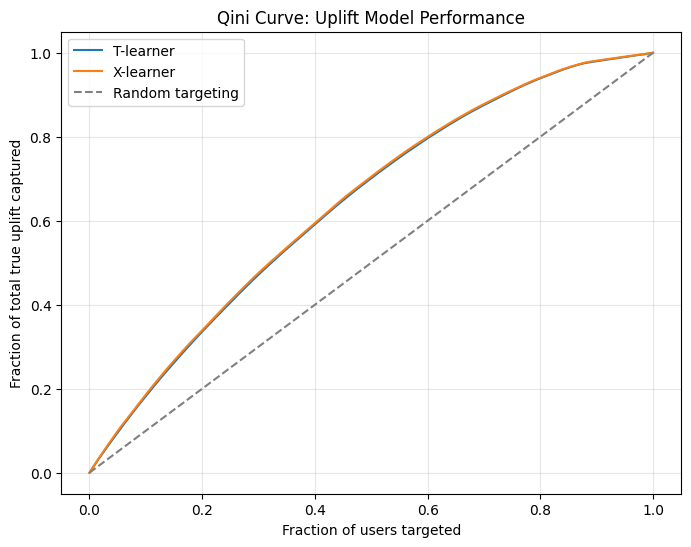

In [61]:
import matplotlib.pyplot as plt

def qini_curve(uplift_scores, true_effects, label):
    # Sort users by PREDICTED uplift, descending
    order = np.argsort(-uplift_scores)
    sorted_true_effects = np.array(true_effects)[order]

    # Cumulative sum of true effect as we target more and more users (by predicted rank)
    cumulative_gain = np.cumsum(sorted_true_effects)

    # Normalize: x-axis = fraction of population targeted, y-axis = fraction of total possible gain captured
    fraction_targeted = np.arange(1, len(cumulative_gain) + 1) / len(cumulative_gain)
    normalized_gain = cumulative_gain / cumulative_gain[-1]

    plt.plot(fraction_targeted, normalized_gain, label=label)

plt.figure(figsize=(8, 6))
qini_curve(estimated_uplift_tlearner, true_effect_test, "T-learner")
qini_curve(estimated_uplift_xlearner, true_effect_test, "X-learner")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random targeting')
plt.xlabel("Fraction of users targeted")
plt.ylabel("Fraction of total true uplift captured")
plt.title("Qini Curve: Uplift Model Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('qini_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Level 7: Evaluation
- Verified predictions against held-out true treatment effects (never seen during training)
- Spearman rank correlation: T-learner 0.96, X-learner 0.98 — both very high
- Qini curve: both models substantially outperform random targeting; targeting top 20%
  of users by predicted uplift captures ~35% of total achievable benefit (vs 20% for random)
- X-learner shows a modest edge over T-learner, consistent with theory, though the gap
  is small here since our treatment assignment was a clean 50/50 random split